# Phase 6: Optimization (ONNX + INT8)

Export EfficientNet-B0 to ONNX, quantize to INT8, and benchmark CPU latency.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import random
import sys

import numpy as np
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.dataset import Ham10000Dataset, build_image_index
from src.models.efficientnet import MelanomaClassifier
from src.optimization.benchmarker import benchmark_onnx_model
from src.optimization.onnx_exporter import export_to_onnx
from src.optimization.quantizer import quantize_model_int8
from src.preprocessing.augmentation import get_val_transforms

artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(json.dumps({"project_root": str(project_root), "device": str(device)}, indent=2))

{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "device": "cuda"
}


/home/selba/Desktop/ENSIAS/Mlops/PFA/code/.venv/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
config_path = project_root / "configs" / "training" / "efficientnet_b0.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
set_seed(int(config.get("seed", 42)))

model_cfg = config.get("model", {})
model = MelanomaClassifier(
    model_name=model_cfg.get("name", "efficientnet_b0"),
    num_classes=int(model_cfg.get("num_classes", 2)),
    pretrained=bool(model_cfg.get("pretrained", True)),
    dropout_rate=float(model_cfg.get("dropout_rate", 0.3)),
)

run_summary_path = artifact_dir / "training_full_run_summary.json"
run_id = None
if run_summary_path.exists():
    run_id = json.loads(run_summary_path.read_text(encoding="utf-8")).get("run_id")

checkpoint_candidates = []
if run_id is not None:
    mlflow_root = project_root / "mlflow"
    if mlflow_root.exists():
        for path in mlflow_root.rglob("best_model.pt"):
            if run_id in str(path):
                checkpoint_candidates.append(path)
checkpoint_candidates.extend([
    project_root / "models" / "checkpoints" / "best_model.pt",
    project_root / "notebooks" / "models" / "checkpoints" / "best_model.pt",
])

checkpoint_path = next((path for path in checkpoint_candidates if path.exists()), None)
if checkpoint_path is None:
    tried = ", ".join(str(path) for path in checkpoint_candidates)
    raise FileNotFoundError(f"Missing checkpoint. Tried: {tried}")
checkpoint = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to("cpu")
model.eval()

print(json.dumps({"checkpoint_path": str(checkpoint_path), "run_id": run_id}, indent=2))

{
  "checkpoint_path": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/mlflow/323210160227859698/9c74ae3a097a4f2f968767c0882c9262/artifacts/best_model.pt",
  "run_id": "9c74ae3a097a4f2f968767c0882c9262"
}


In [3]:
onnx_dir = project_root / "models" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)
fp32_onnx_path = onnx_dir / "efficientnet_b0_fp32.onnx"

fp32_path = export_to_onnx(
    model,
    output_path=str(fp32_onnx_path),
    input_size=int(config.get("data", {}).get("input_size", 224)),
)

fp32_size_mb = fp32_onnx_path.stat().st_size / 1024 / 1024
print(f"Saved FP32 ONNX to {fp32_path} ({fp32_size_mb:.2f} MB)")
fp32_path

Saved FP32 ONNX to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/models/onnx/efficientnet_b0_fp32.onnx (16.55 MB)


'/home/selba/Desktop/ENSIAS/Mlops/PFA/code/models/onnx/efficientnet_b0_fp32.onnx'

In [4]:
data_root = project_root / "data"
train_df = pd.read_csv(data_root / "splits" / "train_split.csv")
test_df = pd.read_csv(data_root / "splits" / "test_split.csv")

def ensure_label(df: pd.DataFrame) -> pd.DataFrame:
    if "label" in df.columns:
        return df
    df = df.copy()
    df["label"] = (df["dx"] == "mel").astype(int)
    return df

train_df = ensure_label(train_df)
test_df = ensure_label(test_df)

image_index = build_image_index(data_root / "raw")
val_transforms = get_val_transforms()

train_dataset = Ham10000Dataset(train_df, image_index, transforms=val_transforms)
test_dataset = Ham10000Dataset(test_df, image_index, transforms=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

int8_dynamic_path = onnx_dir / "efficientnet_b0_int8_dynamic.onnx"
int8_static_path = onnx_dir / "efficientnet_b0_int8.onnx"

int8_dynamic = quantize_model_int8(
    fp32_onnx_path=str(fp32_onnx_path),
    output_path=str(int8_dynamic_path),
    strategy="dynamic",
)
int8_static = quantize_model_int8(
    fp32_onnx_path=str(fp32_onnx_path),
    output_path=str(int8_static_path),
    calibration_loader=train_loader,
    strategy="static",
    quant_format="qdq",
    activation_type="quint8",
    per_channel=True,
    n_samples=500,
)

size_summary = {
    "fp32_mb": fp32_onnx_path.stat().st_size / 1024 / 1024,
    "int8_dynamic_mb": int8_dynamic_path.stat().st_size / 1024 / 1024,
    "int8_static_mb": int8_static_path.stat().st_size / 1024 / 1024,
}
size_summary_path = artifact_dir / "onnx_size_summary.json"
size_summary_path.write_text(json.dumps(size_summary, indent=2), encoding="utf-8")
print(f"Saved size summary to {size_summary_path}")
size_summary

Saved size summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/onnx_size_summary.json


{'fp32_mb': 16.548988342285156,
 'int8_dynamic_mb': 4.473610877990723,
 'int8_static_mb': 4.9695892333984375}

In [5]:
import onnxruntime as ort
from sklearn.metrics import roc_auc_score

def evaluate_onnx_auc(onnx_path: Path, loader: DataLoader) -> float:
    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    all_probs = []
    all_labels = []
    for batch in loader:
        images = batch["image"].numpy()
        labels = batch["label"].numpy()
        logits = session.run(None, {input_name: images})[0]
        exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
        probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        all_probs.extend(probs[:, 1])
        all_labels.extend(labels)
    return float(roc_auc_score(np.array(all_labels), np.array(all_probs)))

auc_fp32 = evaluate_onnx_auc(fp32_onnx_path, test_loader)
auc_int8 = evaluate_onnx_auc(int8_static_path, test_loader)
auc_dynamic = None
try:
    auc_dynamic = evaluate_onnx_auc(int8_dynamic_path, test_loader)
except Exception as exc:
    print(f"Dynamic INT8 eval failed: {exc}")

auc_summary = {
    "fp32_auc": auc_fp32,
    "int8_static_auc": auc_int8,
    "int8_dynamic_auc": auc_dynamic,
    "static_auc_drop": auc_fp32 - auc_int8,
    "dynamic_auc_drop": None if auc_dynamic is None else auc_fp32 - auc_dynamic,
}
auc_summary_path = artifact_dir / "onnx_auc_summary.json"
auc_summary_path.write_text(json.dumps(auc_summary, indent=2), encoding="utf-8")
print(f"Saved AUC summary to {auc_summary_path}")
auc_summary

Dynamic INT8 eval failed: [ONNXRuntimeError] : 9 : NOT_IMPLEMENTED : Could not find an implementation for ConvInteger(10) node with name '/backbone/conv_stem/Conv_quant'
Saved AUC summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/onnx_auc_summary.json


{'fp32_auc': 0.8577828906086593,
 'int8_static_auc': 0.7293850658857979,
 'int8_dynamic_auc': None,
 'static_auc_drop': 0.12839782472286143,
 'dynamic_auc_drop': None}

Saved benchmark results to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/onnx_benchmark.json
Saved latency plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/onnx_latency.png


{'benchmarks': {'fp32': {'model_path': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/models/onnx/efficientnet_b0_fp32.onnx',
   'model_size_mb': 16.548988342285156,
   'providers': ['CPUExecutionProvider'],
   'n_runs': 200,
   'mean_ms': 6.7709387150011935,
   'std_ms': 1.7124320466919538,
   'p50_ms': 6.011387499995635,
   'p95_ms': 10.087196450069767,
   'p99_ms': 12.594506009929765,
   'min_ms': 5.07227299999613,
   'max_ms': 14.016303999937918,
   'throughput_fps': 147.69000903589242},
  'int8_static': {'model_path': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/models/onnx/efficientnet_b0_int8.onnx',
   'model_size_mb': 4.9695892333984375,
   'providers': ['CPUExecutionProvider'],
   'n_runs': 200,
   'mean_ms': 4.946452529998737,
   'std_ms': 0.6770183797947954,
   'p50_ms': 4.770741999948314,
   'p95_ms': 6.382836450075042,
   'p99_ms': 7.509087309955474,
   'min_ms': 4.24782300001425,
   'max_ms': 8.50619999994251,
   'throughput_fps': 202.16508577314806}},
 'latency_plot': '/home/s

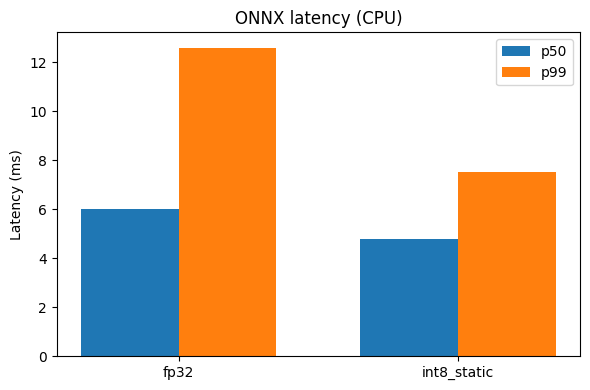

In [6]:
import matplotlib.pyplot as plt

bench_fp32 = benchmark_onnx_model(str(fp32_onnx_path))
bench_int8 = benchmark_onnx_model(str(int8_static_path))

benchmarks = {"fp32": bench_fp32, "int8_static": bench_int8}
benchmark_path = artifact_dir / "onnx_benchmark.json"
benchmark_path.write_text(json.dumps(benchmarks, indent=2), encoding="utf-8")
print(f"Saved benchmark results to {benchmark_path}")

labels = ["fp32", "int8_static"]
p50 = [bench_fp32["p50_ms"], bench_int8["p50_ms"]]
p99 = [bench_fp32["p99_ms"], bench_int8["p99_ms"]]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, p50, width, label="p50")
ax.bar(x + width / 2, p99, width, label="p99")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Latency (ms)")
ax.set_title("ONNX latency (CPU)")
ax.legend()
fig.tight_layout()
latency_plot_path = figure_dir / "onnx_latency.png"
fig.savefig(latency_plot_path, dpi=160, bbox_inches="tight")
print(f"Saved latency plot to {latency_plot_path}")

{"benchmarks": benchmarks, "latency_plot": str(latency_plot_path)}